In [52]:
import math
import numpy as np
from itertools import product
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Словарь: 5 токенов
VOCAB = ['A', 'B', 'C', 'D', '|']
VOCAB_SIZE = len(VOCAB)  # 5

# Прямой и обратный маппинг
char_to_id = {ch: i for i, ch in enumerate(VOCAB)}
id_to_char = {i: ch for i, ch in enumerate(VOCAB)}


def make_example(input_str):
    """
    input_str: строка из 4 символов, например 'ABAD'
    возвращает: список id длины 9, например [0,1,0,3,4,0,1,0,3]
    """
    full = input_str + '|' + input_str
    return [char_to_id[ch] for ch in full]


print(make_example('ABAD'))
# [0, 1, 0, 3, 4, 0, 1, 0, 3]

[0, 1, 0, 3, 4, 0, 1, 0, 3]


## Формирование датасета

In [53]:
def build_dataset():
    examples = []
    # product('ABCD', repeat=4) генерит все 4-буквенные комбинации:
    # ('A','A','A','A'), ('A','A','A','B'), ..., ('D','D','D','D')
    for combo in product('ABCD', repeat=4):
        input_str = ''.join(combo)         # ('A','B','A','D') -> 'ABAD'
        examples.append(make_example(input_str))
    return torch.tensor(examples, dtype=torch.long)

dataset = build_dataset()
print("dataset.shape ", dataset.shape)   # torch.Size([256, 9])
print("dataset[0] ", dataset[0])      # tensor([0, 0, 0, 0, 4, 0, 0, 0, 0])  — пример для 'AAAA'
print("dataset[27] ", dataset[27])     # tensor([0, 1, 0, 3, 4, 0, 1, 0, 3])  — пример для 'ABAD'


# dataset имеет форму [256, 9]
inputs  = dataset[:, :-1]   # все примеры, токены 0..7  → форма [256, 8]
targets = dataset[:,  1:]   # все примеры, токены 1..8  → форма [256, 8]

print("inputs[27]) ", inputs[27])   # tensor([0, 1, 0, 3, 4, 0, 1, 0])
print("targets[27] ", targets[27])  # tensor([1, 0, 3, 4, 0, 1, 0, 3])


# Создаём маску длины 8 (как у inputs/targets)
loss_mask = torch.zeros(8, dtype=torch.bool)
loss_mask[3:8] = True   # включаем позиции 3, 4, 5, 6, 7

print("loss_mask ", loss_mask)
# tensor([False, False, False,  True,  True,  True,  True,  True])


dataset.shape  torch.Size([256, 9])
dataset[0]  tensor([0, 0, 0, 0, 4, 0, 0, 0, 0])
dataset[27]  tensor([0, 1, 2, 3, 4, 0, 1, 2, 3])
inputs[27])  tensor([0, 1, 2, 3, 4, 0, 1, 2])
targets[27]  tensor([1, 2, 3, 4, 0, 1, 2, 3])
loss_mask  tensor([False, False, False,  True,  True,  True,  True,  True])


## Embedding слой

In [54]:
class Embedding(nn.Module):
    def __init__(self, vocab_size, max_len, d_model):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb   = nn.Embedding(max_len,   d_model)

    def forward(self, x):
        # x имеет форму [B, T] — токены (целые числа)
        B, T = x.shape
        positions = torch.arange(T, device=x.device)   # [0, 1, ..., T-1]
        return self.token_emb(x) + self.pos_emb(positions)


# Тест Embedding слоя
emb = Embedding(vocab_size=5, max_len=9, d_model=8)
test_input = torch.tensor([[0, 1, 0, 3, 4, 0, 1, 0]])  # один пример 'ABAD|ABA'
out = emb(test_input)
print(out.shape)   # torch.Size([1, 8, 8])

torch.Size([1, 8, 8])


## Блок Attention'а

In [55]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.last_attn = None   # ← добавили

    def forward(self, x):
        B, T, D = x.shape
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)

        scores = q @ k.transpose(-2, -1) / math.sqrt(D)
        mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~mask, float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        self.last_attn = attn   # ← добавили: сохраняем для loss
        out = attn @ v
        out = self.W_o(out)
        return out


attn = CausalSelfAttention(d_model=8)
test_input = torch.randn(2, 8, 8)   # 2 примера, 8 позиций, 8-мерные эмбеддинги
out = attn(test_input)
print(out.shape)   # torch.Size([2, 8, 8])

torch.Size([2, 8, 8])


## Последний слой и сборка

In [56]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # x имеет форму [B, T, d_model]
        x = self.linear1(x)               # [B, T, d_ff]
        x = torch.relu(x)                 # [B, T, d_ff]
        x = self.linear2(x)               # [B, T, d_model]
        return x


class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.ffn  = FeedForward(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))    # Pre-LN attention + residual
        x = x + self.ffn(self.ln2(x))     # Pre-LN FFN + residual
        return x


class TransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, d_ff):
        super().__init__()
        self.embedding = Embedding(vocab_size, max_len, d_model)
        self.block     = TransformerBlock(d_model, d_ff)
        self.ln_final  = nn.LayerNorm(d_model)
        self.head      = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x имеет форму [B, T] — токены
        x = self.embedding(x)         # [B, T, d_model]
        x = self.block(x)             # [B, T, d_model]
        x = self.ln_final(x)          # [B, T, d_model]
        logits = self.head(x)         # [B, T, vocab_size]
        return logits


model = TransformerLM(vocab_size=5, max_len=9, d_model=8, d_ff=16)
test_input = torch.tensor([[0, 1, 0, 3, 4, 0, 1, 0]])  # 'ABAD|ABA', форма [1, 8]
logits = model(test_input)
print(logits.shape)   # torch.Size([1, 8, 5])

# Сосчитаем параметры
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params}")

torch.Size([1, 8, 5])
Total parameters: 741


## Loss и обучение

In [57]:
def compute_loss(logits, targets, loss_mask):
    """
    logits:    [B, T, vocab_size] — предсказания модели
    targets:   [B, T]              — правильные id токенов
    loss_mask: [T]                 — bool, какие позиции учитывать
    """
    B, T, V = logits.shape

    # Cross-entropy ожидает форму [N, C] для logits и [N] для targets
    loss_per_token = nn.functional.cross_entropy(
        logits.reshape(B * T, V),
        targets.reshape(B * T),
        reduction='none'
    )   # [B * T]

    # Применяем маску
    loss_per_token = loss_per_token.reshape(B, T)
    mask = loss_mask.unsqueeze(0).expand(B, T)   # [B, T]
    masked_loss = loss_per_token[mask]            # одномерный тензор

    return masked_loss.mean()



# Создаём модель и оптимизатор заново (на случай повторного запуска)
torch.manual_seed(42)
model = TransformerLM(vocab_size=5, max_len=9, d_model=8, d_ff=16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Обучение
n_epochs = 2000
loss_history = []
for epoch in range(n_epochs):
    logits = model(inputs)
    loss = compute_loss(logits, targets, loss_mask)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | loss = {loss.item():.4f}")

Epoch    0 | loss = 1.7903
Epoch  100 | loss = 1.2804
Epoch  200 | loss = 0.7334
Epoch  300 | loss = 0.1291
Epoch  400 | loss = 0.0477
Epoch  500 | loss = 0.0252
Epoch  600 | loss = 0.0157
Epoch  700 | loss = 0.0108
Epoch  800 | loss = 0.0079
Epoch  900 | loss = 0.0061
Epoch 1000 | loss = 0.0048
Epoch 1100 | loss = 0.0039
Epoch 1200 | loss = 0.0032
Epoch 1300 | loss = 0.0027
Epoch 1400 | loss = 0.0023
Epoch 1500 | loss = 0.0020
Epoch 1600 | loss = 0.0017
Epoch 1700 | loss = 0.0015
Epoch 1800 | loss = 0.0013
Epoch 1900 | loss = 0.0012


## Оценка точности

In [58]:
@torch.no_grad()
def evaluate(model, inputs, targets, loss_mask):
    model.eval()
    logits = model(inputs)                # [256, 8, 5]
    predictions = logits.argmax(dim=-1)   # [256, 8]

    # Проверяем только позиции, входящие в loss_mask
    correct = (predictions == targets) & loss_mask.unsqueeze(0)
    total_positions = loss_mask.sum() * inputs.shape[0]  # 5 * 256 = 1280
    accuracy = correct.sum().item() / total_positions.item()

    model.train()
    return accuracy

acc = evaluate(model, inputs, targets, loss_mask)
print(f"Accuracy on masked positions: {acc * 100:.2f}%")

Accuracy on masked positions: 100.00%


## Смотрим Attention pattern

In [59]:
@torch.no_grad()
def get_attention_pattern(model, example_input):
    """
    example_input: [1, T] — один пример
    возвращает: [T, T] — attention pattern для одного примера
    """
    model.eval()
    # Прогоняем через embedding и LN1
    x = model.embedding(example_input)
    x_norm = model.block.ln1(x)

    # Вручную считаем attention, чтобы достать pattern
    attn_module = model.block.attn
    q = attn_module.W_q(x_norm)
    k = attn_module.W_k(x_norm)

    scores = q @ k.transpose(-2, -1) / math.sqrt(attn_module.d_model)
    T = example_input.shape[1]
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float('-inf'))
    attn = torch.softmax(scores, dim=-1)

    return attn[0]   # снимаем batch-ось → [T, T]


# Берём первый пример датасета и смотрим attention
example = inputs[0:1]   # [1, 8]
print("Input tokens:", example[0].tolist())
print("Input chars: ", [id_to_char[t.item()] for t in example[0]])

pattern = get_attention_pattern(model, example)
print("\nAttention pattern (rows = queries, cols = keys):")
print(pattern.numpy().round(2))

Input tokens: [0, 0, 0, 0, 4, 0, 0, 0]
Input chars:  ['A', 'A', 'A', 'A', '|', 'A', 'A', 'A']

Attention pattern (rows = queries, cols = keys):
[[1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.25 0.75 0.   0.   0.   0.   0.   0.  ]
 [0.01 0.95 0.04 0.   0.   0.   0.   0.  ]
 [0.   0.16 0.17 0.66 0.   0.   0.   0.  ]
 [0.98 0.02 0.   0.   0.   0.   0.   0.  ]
 [0.02 0.8  0.04 0.03 0.06 0.05 0.   0.  ]
 [0.   0.04 0.51 0.09 0.33 0.02 0.   0.  ]
 [0.   0.   0.08 0.61 0.29 0.01 0.   0.01]]


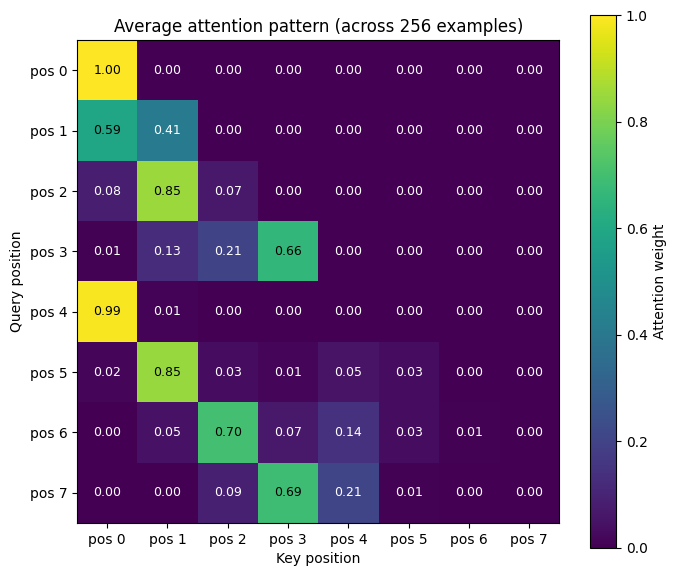

In [60]:
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def get_average_attention(model, all_inputs):
    """Усредняем attention pattern по всему датасету"""
    patterns = []
    for i in range(all_inputs.shape[0]):
        p = get_attention_pattern(model, all_inputs[i:i+1])
        patterns.append(p)
    return torch.stack(patterns).mean(dim=0).numpy()

avg_pattern = get_average_attention(model, inputs)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(avg_pattern, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels([f"pos {i}" for i in range(8)])
ax.set_yticklabels([f"pos {i}" for i in range(8)])
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title("Average attention pattern (across 256 examples)")

# Подписи значений в ячейках
for i in range(8):
    for j in range(8):
        v = avg_pattern[i, j]
        color = "white" if v < 0.5 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=color, fontsize=9)

plt.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_pattern.png", dpi=150)
plt.show()

## Проверка на float_16

In [61]:
@torch.no_grad()
def test_fp16(model, inputs, targets, loss_mask):
    model_fp16 = TransformerLM(
        vocab_size=5, max_len=9, d_model=8, d_ff=16
    ).half()  # half() = перевести в float16

    # Скопируем веса из обученной модели, переведя в fp16
    model_fp16.load_state_dict(
        {k: v.half() for k, v in model.state_dict().items()}
    )
    model_fp16.eval()

    # Считаем в fp16
    logits = model_fp16(inputs)
    predictions = logits.argmax(dim=-1)
    correct = (predictions == targets) & loss_mask.unsqueeze(0)
    total = loss_mask.sum() * inputs.shape[0]
    acc = correct.sum().item() / total.item()
    return acc

acc_fp16 = test_fp16(model, inputs, targets, loss_mask)
print(f"Accuracy in float16: {acc_fp16 * 100:.2f}%")

Accuracy in float16: 100.00%


# Дообучение модели для hardmax-инференса

In [62]:
def attention_entropy(attn, loss_mask, eps=1e-9):
    """
    attn: [B, T, T] — attention pattern (после softmax)
    loss_mask: [T] — какие позиции учитывать
    Возвращает среднюю энтропию по интересующим позициям.
    """
    # Энтропия по последней оси: -sum p log p
    ent = -(attn * torch.log(attn + eps)).sum(dim=-1)   # [B, T]
    # Берём только позиции из loss_mask
    ent_masked = ent[:, loss_mask]                        # [B, num_relevant]
    return ent_masked.mean()


def compute_loss_with_entropy(model, logits, targets, loss_mask, entropy_weight=0.5):
    """
    Возвращает (total_loss, ce_value, entropy_value).
    total_loss используется для backward.
    ce и entropy — для логирования.
    """
    B, T, V = logits.shape

    # Стандартный cross-entropy с маской (как раньше)
    loss_per_token = nn.functional.cross_entropy(
        logits.reshape(B * T, V),
        targets.reshape(B * T),
        reduction='none'
    ).reshape(B, T)
    mask = loss_mask.unsqueeze(0).expand(B, T)
    ce = loss_per_token[mask].mean()

    # Энтропия attention
    attn = model.block.attn.last_attn
    ent = attention_entropy(attn, loss_mask)

    total = ce + entropy_weight * ent
    return total, ce.item(), ent.item()

n_extra_epochs = 4000
for epoch in range(n_extra_epochs):
    logits = model(inputs)
    loss, ce, ent = compute_loss_with_entropy(
        model, logits, targets, loss_mask, entropy_weight=0.5
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | total = {loss.item():.4f} | "
              f"ce = {ce:.4f} | ent = {ent:.4f}")

Epoch    0 | total = 0.3258 | ce = 0.0010 | ent = 0.6495
Epoch  200 | total = 0.0017 | ce = 0.0010 | ent = 0.0012
Epoch  400 | total = 0.0010 | ce = 0.0008 | ent = 0.0005
Epoch  600 | total = 0.0007 | ce = 0.0006 | ent = 0.0003
Epoch  800 | total = 0.0006 | ce = 0.0005 | ent = 0.0002
Epoch 1000 | total = 0.0005 | ce = 0.0004 | ent = 0.0001
Epoch 1200 | total = 0.0004 | ce = 0.0003 | ent = 0.0001
Epoch 1400 | total = 0.0003 | ce = 0.0003 | ent = 0.0001
Epoch 1600 | total = 0.0003 | ce = 0.0002 | ent = 0.0001
Epoch 1800 | total = 0.0002 | ce = 0.0002 | ent = 0.0001
Epoch 2000 | total = 0.0002 | ce = 0.0002 | ent = 0.0000
Epoch 2200 | total = 0.0002 | ce = 0.0002 | ent = 0.0000
Epoch 2400 | total = 0.0002 | ce = 0.0001 | ent = 0.0000
Epoch 2600 | total = 0.0001 | ce = 0.0001 | ent = 0.0000
Epoch 2800 | total = 0.0001 | ce = 0.0001 | ent = 0.0000
Epoch 3000 | total = 0.0001 | ce = 0.0001 | ent = 0.0000
Epoch 3200 | total = 0.0001 | ce = 0.0001 | ent = 0.0000
Epoch 3400 | total = 0.0001 | c

## Golden reference

In [63]:
import torch

@torch.no_grad()
def golden_forward_full9(model, full_sequence):
    """
    full_sequence: [1, 9] — полная последовательность (вход + разделитель + копия)
    Считает hardmax-forward для всех 9 позиций.
    """
    model.eval()
    trace = {}

    trace["00_tokens"] = full_sequence[0].clone()

    x = model.embedding(full_sequence)
    trace["01_embedding"] = x[0].clone()

    x_norm1 = model.block.ln1(x)
    trace["02_ln1"] = x_norm1[0].clone()

    q = model.block.attn.W_q(x_norm1)
    k = model.block.attn.W_k(x_norm1)
    v = model.block.attn.W_v(x_norm1)
    trace["03_q"] = q[0].clone()
    trace["03_k"] = k[0].clone()
    trace["03_v"] = v[0].clone()

    T = 9
    scores = q @ k.transpose(-2, -1) / math.sqrt(model.block.attn.d_model)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float('-inf'))
    trace["04_scores"] = scores[0].clone()

    argmax_idx = scores.argmax(dim=-1, keepdim=True)
    hardmax = torch.zeros_like(scores)
    hardmax.scatter_(-1, argmax_idx, 1.0)
    trace["05_attn_argmax"] = argmax_idx[0, :, 0].clone()

    av = hardmax @ v
    trace["06_av"] = av[0].clone()
    attn_out = model.block.attn.W_o(av)
    trace["07_attn_out"] = attn_out[0].clone()
    x_after_attn = x + attn_out
    trace["08_after_attn_residual"] = x_after_attn[0].clone()

    x_norm2 = model.block.ln2(x_after_attn)
    trace["09_ln2"] = x_norm2[0].clone()
    h = torch.relu(model.block.ffn.linear1(x_norm2))
    trace["10_ffn_hidden"] = h[0].clone()
    ffn_out = model.block.ffn.linear2(h)
    trace["11_ffn_out"] = ffn_out[0].clone()
    x_final = x_after_attn + ffn_out
    trace["12_after_ffn_residual"] = x_final[0].clone()

    x_final_ln = model.ln_final(x_final)
    trace["13_ln_final"] = x_final_ln[0].clone()
    logits = model.head(x_final_ln)
    trace["14_logits"] = logits[0].clone()
    predictions = logits.argmax(dim=-1)
    trace["15_predictions"] = predictions[0].clone()

    return trace


# Полный 9-токенный вход: A B A D | A B A D = [0, 1, 0, 3, 4, 0, 1, 0, 3]
full_seq = torch.tensor([[0, 1, 0, 3, 4, 0, 1, 0, 3]])
trace_full = golden_forward_full9(model, full_seq)

np.savez(
    "trace_detailed.npz",
    **{name: t.numpy() for name, t in trace_full.items()},
)

# Распечатаем embedding для сверки
print("Embedding row by row (golden, fp16):")
for i, row in enumerate(trace_full["01_embedding"].to(torch.float16).numpy()):
    print(f"  pos {i}: {row}")

Embedding row by row (golden, fp16):
  pos 0: [ 0.01448  0.1191   2.111   -0.851   -0.06537 -0.2754   1.653   -1.364  ]
  pos 1: [-1.331   1.347  -1.882  -0.5127  0.4763  0.5273 -0.3413 -0.686 ]
  pos 2: [ 0.9775  0.4294 -0.1526 -1.326   1.105  -1.515   0.2428  1.388 ]
  pos 3: [ 3.416   0.4365  1.037   0.2206  0.4558  1.304  -2.44    1.546 ]
  pos 4: [-0.998    0.10815 -0.3564   3.068    1.223   -1.7705  -1.194   -1.233  ]
  pos 5: [ 0.9014  2.379   1.919  -1.187   1.587  -2.049   0.3875 -0.683 ]
  pos 6: [-1.503   1.984   0.2274 -1.269  -1.595   0.625  -0.9673  0.499 ]
  pos 7: [ 2.906   1.766  -1.223  -2.54    0.5874  1.092   1.014  -0.3887]
  pos 8: [ 1.348   0.4487 -0.8345  0.229   0.508   1.374  -1.354   0.706 ]


In [71]:
import numpy as np

# 1) Берём первую строку embedding из golden trace
trace = np.load("trace_detailed.npz")
golden_row0 = trace["01_embedding"][0]   # форма [8], float32

# 2) Переводим в float16 — это формат, в котором веса и активации
#    физически лежат в памяти sim8
row_fp16 = golden_row0.astype(np.float16)

# 3) Берём сырые байты (little-endian, как в sim8 по спеке)
row_bytes = row_fp16.tobytes()
hex_str = " ".join(f"{b:02X}" for b in row_bytes)

print(f"Golden row 0 (fp16, hex): {hex_str}")
print(f"SIM8   row 0 (hex):       80 23 A0 2F 39 40 CE BA 30 AC 69 B4 9D 3E 74 BD")

Golden row 0 (fp16, hex): 6A 23 9F 2F 39 40 CF BA 2F AC 68 B4 9D 3E 75 BD
SIM8   row 0 (hex):       80 23 A0 2F 39 40 CE BA 30 AC 69 B4 9D 3E 74 BD


## Verify hardmax

In [69]:
@torch.no_grad()
def hardmax_forward(model, x):
    """
    Forward pass с заменой softmax на hardmax внутри attention.
    Всё остальное — без изменений.
    """
    model.eval()

    # 1. Embedding
    h = model.embedding(x)

    # 2. Pre-LN attention с hardmax
    x_norm = model.block.ln1(h)
    q = model.block.attn.W_q(x_norm)
    k = model.block.attn.W_k(x_norm)
    v = model.block.attn.W_v(x_norm)

    B, T, D = q.shape
    scores = q @ k.transpose(-2, -1) / math.sqrt(D)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float('-inf'))

    # HARDMAX: для каждой строки выбираем argmax, ставим 1, остальное 0
    argmax_idx = scores.argmax(dim=-1, keepdim=True)            # [B, T, 1]
    hardmax = torch.zeros_like(scores)
    hardmax.scatter_(-1, argmax_idx, 1.0)                        # one-hot

    av = hardmax @ v
    attn_out = model.block.attn.W_o(av)
    h = h + attn_out

    # 3. Pre-LN FFN
    x_norm2 = model.block.ln2(h)
    h2 = torch.relu(model.block.ffn.linear1(x_norm2))
    h = h + model.block.ffn.linear2(h2)

    # 4. Final
    h = model.ln_final(h)
    logits = model.head(h)
    return logits


# Прогоняем все 256 примеров с hardmax
logits_hm = hardmax_forward(model, inputs)
preds_hm = logits_hm.argmax(dim=-1)
correct = (preds_hm == targets) & loss_mask.unsqueeze(0)
total = loss_mask.sum() * inputs.shape[0]
acc_hm = correct.sum().item() / total.item()
print(f"Accuracy with hardmax inference: {acc_hm * 100:.2f}%")

Accuracy with hardmax inference: 100.00%


# Подготовка к sim8 реализации

## Извлечение весов 

In [65]:
print("=" * 60)
print("Все обучаемые параметры модели")
print("=" * 60)

total = 0
for name, param in model.named_parameters():
    n = param.numel()
    total += n
    print(f"{name:40s} {tuple(param.shape)!s:20s} {n:5d}")

print("-" * 60)
print(f"{'TOTAL':60s} {total}")

Все обучаемые параметры модели
embedding.token_emb.weight               (5, 8)                  40
embedding.pos_emb.weight                 (9, 8)                  72
block.ln1.weight                         (8,)                     8
block.ln1.bias                           (8,)                     8
block.attn.W_q.weight                    (8, 8)                  64
block.attn.W_k.weight                    (8, 8)                  64
block.attn.W_v.weight                    (8, 8)                  64
block.attn.W_o.weight                    (8, 8)                  64
block.ln2.weight                         (8,)                     8
block.ln2.bias                           (8,)                     8
block.ffn.linear1.weight                 (16, 8)                128
block.ffn.linear1.bias                   (16,)                   16
block.ffn.linear2.weight                 (8, 16)                128
block.ffn.linear2.bias                   (8,)                     8
ln_final.weight  

## Сохранение весов в бинарный формат

In [66]:
def export_weights(model, path="weights.bin"):
    """
    Сохраняет все веса модели в float16 в фиксированном порядке.
    Возвращает список (name, offset_bytes, shape, n_elements).
    """
    # Фиксированный порядок — критично, sim8 будет ожидать ровно этот
    order = [
        "embedding.token_emb.weight",
        "embedding.pos_emb.weight",
        "block.ln1.weight",
        "block.ln1.bias",
        "block.attn.W_q.weight",
        "block.attn.W_k.weight",
        "block.attn.W_v.weight",
        "block.attn.W_o.weight",
        "block.ln2.weight",
        "block.ln2.bias",
        "block.ffn.linear1.weight",
        "block.ffn.linear1.bias",
        "block.ffn.linear2.weight",
        "block.ffn.linear2.bias",
        "ln_final.weight",
        "ln_final.bias",
        "head.weight",
        "head.bias",
    ]

    state = model.state_dict()
    layout = []
    chunks = []
    offset = 0

    for name in order:
        t = state[name].detach().cpu().to(torch.float16).numpy()
        flat = t.flatten()
        layout.append({
            "name":      name,
            "offset":    offset,
            "shape":     tuple(t.shape),
            "n_elem":    flat.size,
            "n_bytes":   flat.nbytes,
        })
        chunks.append(flat)
        offset += flat.nbytes

    blob = np.concatenate(chunks).astype(np.float16)
    blob.tofile(path)
    print(f"Wrote {offset} bytes to {path}")
    return layout


layout = export_weights(model, "weights.bin")

print(f"\n{'name':35s} {'offset':>7s} {'shape':>12s} {'bytes':>6s}")
print("-" * 65)
for entry in layout:
    print(f"{entry['name']:35s} {entry['offset']:7d} "
          f"{str(entry['shape']):>12s} {entry['n_bytes']:6d}")

Wrote 1482 bytes to weights.bin

name                                 offset        shape  bytes
-----------------------------------------------------------------
embedding.token_emb.weight                0       (5, 8)     80
embedding.pos_emb.weight                 80       (9, 8)    144
block.ln1.weight                        224         (8,)     16
block.ln1.bias                          240         (8,)     16
block.attn.W_q.weight                   256       (8, 8)    128
block.attn.W_k.weight                   384       (8, 8)    128
block.attn.W_v.weight                   512       (8, 8)    128
block.attn.W_o.weight                   640       (8, 8)    128
block.ln2.weight                        768         (8,)     16
block.ln2.bias                          784         (8,)     16
block.ffn.linear1.weight                800      (16, 8)    256
block.ffn.linear1.bias                 1056        (16,)     32
block.ffn.linear2.weight               1088      (8, 16)    256
block

## Сохранение трасс для всех 256 примеров. И одна детальная.

In [67]:
@torch.no_grad()
def export_traces(model, all_inputs, path="traces.npz"):
    """
    Прогоняет все 256 примеров через golden_forward
    и сохраняет ключевые трассы (для верификации).
    """
    model.eval()

    # Сохраняем только финальные предсказания и логиты —
    # этого хватит для верификации ассемблера на всех 256 примерах.
    # Промежуточные трассы можно посмотреть отдельно для одного примера.
    all_logits = []
    all_preds = []

    for i in range(all_inputs.shape[0]):
        ex = all_inputs[i:i+1]
        trace = golden_forward_hardmax(model, ex)
        all_logits.append(trace["14_logits"].numpy())
        all_preds.append(trace["15_predictions"].numpy())

    np.savez(
        path,
        inputs=all_inputs.numpy(),
        logits=np.stack(all_logits),        # [256, 8, 5]
        predictions=np.stack(all_preds),    # [256, 8]
    )
    print(f"Wrote traces for {all_inputs.shape[0]} examples to {path}")


export_traces(model, inputs, "traces.npz")





test_example = inputs[27:28]   # 'ABAD|ABA'
trace = golden_forward_hardmax(model, test_example)

# Сохраним все промежуточные тензоры
np.savez(
    "trace_detailed.npz",
    **{name: t.numpy() for name, t in trace.items()},
)
print("Saved detailed trace for example 'ABAD|ABA' to trace_detailed.npz")

Wrote traces for 256 examples to traces.npz
Saved detailed trace for example 'ABAD|ABA' to trace_detailed.npz


## Генерация 18 отдельных bin файлов

In [68]:
import os

with open("weights.bin", "rb") as f:
    blob = np.frombuffer(f.read(), dtype=np.uint8)

# Те же размеры, что и раньше
sizes_bytes = [
    ("token_emb",   80),
    ("pos_emb",     144),
    ("ln1_gamma",   16),
    ("ln1_beta",    16),
    ("W_q",         128),
    ("W_k",         128),
    ("W_v",         128),
    ("W_o",         128),
    ("ln2_gamma",   16),
    ("ln2_beta",    16),
    ("W1",          256),
    ("b1",          32),
    ("W2",          256),
    ("b2",          16),
    ("lnf_gamma",   16),
    ("lnf_beta",    16),
    ("head_W",      80),
    ("head_b",      10),
]

os.makedirs("weights_split", exist_ok=True)

offset = 0
for name, n in sizes_bytes:
    chunk = blob[offset : offset + n]
    out_path = f"weights_split/{name}.bin"
    with open(out_path, "wb") as f:
        f.write(chunk.tobytes())
    print(f"{name:12s} {n:4d} bytes → {out_path}")
    offset += n

print(f"\nTotal: {offset} bytes")

token_emb      80 bytes → weights_split/token_emb.bin
pos_emb       144 bytes → weights_split/pos_emb.bin
ln1_gamma      16 bytes → weights_split/ln1_gamma.bin
ln1_beta       16 bytes → weights_split/ln1_beta.bin
W_q           128 bytes → weights_split/W_q.bin
W_k           128 bytes → weights_split/W_k.bin
W_v           128 bytes → weights_split/W_v.bin
W_o           128 bytes → weights_split/W_o.bin
ln2_gamma      16 bytes → weights_split/ln2_gamma.bin
ln2_beta       16 bytes → weights_split/ln2_beta.bin
W1            256 bytes → weights_split/W1.bin
b1             32 bytes → weights_split/b1.bin
W2            256 bytes → weights_split/W2.bin
b2             16 bytes → weights_split/b2.bin
lnf_gamma      16 bytes → weights_split/lnf_gamma.bin
lnf_beta       16 bytes → weights_split/lnf_beta.bin
head_W         80 bytes → weights_split/head_W.bin
head_b         10 bytes → weights_split/head_b.bin

Total: 1482 bytes


# Убираем layer norm для экономии кода

In [72]:
class TransformerBlockNoLN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.attn = CausalSelfAttention(d_model)
        self.ffn  = FeedForward(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(x)    # без LN
        x = x + self.ffn(x)     # без LN
        return x


class TransformerLMNoLN(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, d_ff):
        super().__init__()
        self.embedding = Embedding(vocab_size, max_len, d_model)
        self.block     = TransformerBlockNoLN(d_model, d_ff)
        self.head      = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.block(x)
        logits = self.head(x)
        return logits

def analyze_hardmax_errors(model, inputs, targets, loss_mask):
    logits_hm = hardmax_forward(model, inputs)
    preds_hm = logits_hm.argmax(dim=-1)

    # Точность по позициям
    print("Accuracy by position:")
    for pos in range(8):
        correct = (preds_hm[:, pos] == targets[:, pos]).sum().item()
        total = inputs.shape[0]
        marker = " ← важна для нас" if loss_mask[pos] else ""
        print(f"  pos {pos}: {correct}/{total} = {100*correct/total:.1f}%{marker}")

torch.manual_seed(42)
model = TransformerLMNoLN(vocab_size=5, max_len=9, d_model=8, d_ff=16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 6000   # чуть больше, без LN может медленнее сходиться
for epoch in range(n_epochs):
    logits = model(inputs)
    loss, ce, ent = compute_loss_with_entropy(
        model, logits, targets, loss_mask, entropy_weight=0.5
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | total = {loss.item():.4f} | ce = {ce:.4f} | ent = {ent:.4f}")



# 1. Softmax accuracy
acc = evaluate(model, inputs, targets, loss_mask)
print(f"Softmax accuracy: {acc*100:.2f}%")

# 2. Hardmax accuracy
analyze_hardmax_errors(model, inputs, targets, loss_mask)

Epoch    0 | total = 2.8759 | ce = 2.0525 | ent = 1.6467
Epoch  300 | total = 1.0280 | ce = 1.0044 | ent = 0.0471
Epoch  600 | total = 0.8359 | ce = 0.8349 | ent = 0.0020
Epoch  900 | total = 0.8327 | ce = 0.8324 | ent = 0.0007
Epoch 1200 | total = 0.8322 | ce = 0.8320 | ent = 0.0004
Epoch 1500 | total = 0.8320 | ce = 0.8319 | ent = 0.0002
Epoch 1800 | total = 0.8319 | ce = 0.8319 | ent = 0.0002
Epoch 2100 | total = 0.8319 | ce = 0.8318 | ent = 0.0001
Epoch 2400 | total = 0.8319 | ce = 0.8318 | ent = 0.0001
Epoch 2700 | total = 0.8318 | ce = 0.8318 | ent = 0.0001
Epoch 3000 | total = 0.8318 | ce = 0.8318 | ent = 0.0001
Epoch 3300 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 3600 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 3900 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 4200 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 4500 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 4800 | total = 0.8318 | ce = 0.8318 | ent = 0.0000
Epoch 5100 | total = 0.8318 | c

AttributeError: 'TransformerBlockNoLN' object has no attribute 'ln1'